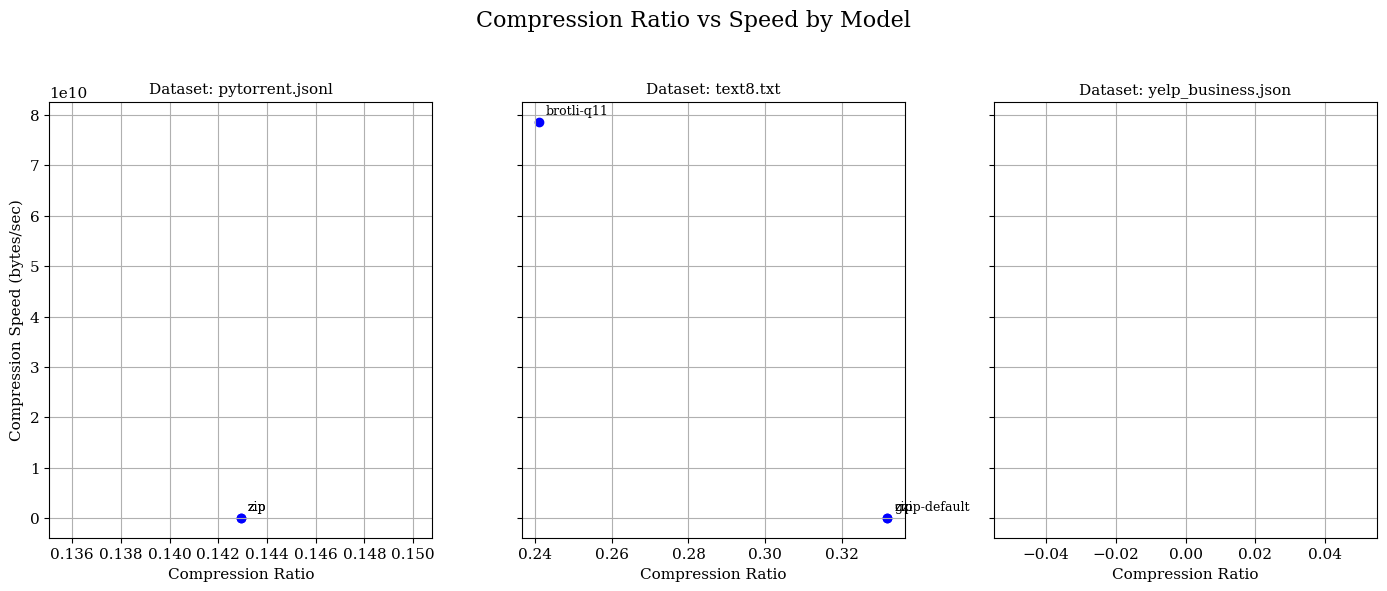

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('ADMS_engines.csv')

# Compute metrics
# Technique --> Model 
df['compression_ratio'] = df['Compressed Size'] / df['Dataset Size']
df['compression_speed'] = df['Dataset Size'] / df['Compression Duration']

# Get unique datasets
datasets = df['Dataset'].unique()


# Create subplots
fig, axes = plt.subplots(1, len(datasets), figsize=(14, 6), sharey=True)

# Ensure axes is iterable
if len(datasets) == 1:
    axes = [axes]

# Plot per dataset
for ax, dataset in zip(axes, datasets):
    subset = df[df['Dataset'] == dataset]
    ax.scatter(subset['compression_ratio'], subset['compression_speed'], color='blue')

    # Add annotations
    for _, row in subset.iterrows():
        ax.annotate(row['Model'],
                    (row['compression_ratio'], row['compression_speed']),
                    textcoords="offset points",
                    xytext=(5,5),
                    ha='left',
                    fontsize=9)

    ax.set_title(f'Dataset: {dataset.split("/")[-1]}')
    ax.set_xlabel('Compression Ratio')
    ax.grid(True)

axes[0].set_ylabel('Compression Speed (bytes/sec)')
fig.suptitle('Compression Ratio vs Speed by Model', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Throughput Plots - per engine

/tmp/ipykernel_1775797/3079727345.py:55: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1775797/3079727345.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(text8_df['Engine'], rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_1775797/3079727345.py:74: UserWarning: 
The palette list has fewer values (0) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/tmp/ipykernel_1775797/3079727345.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(pytorrent_df['Engine'], rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_1775797/3079727345.py:94: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipyk

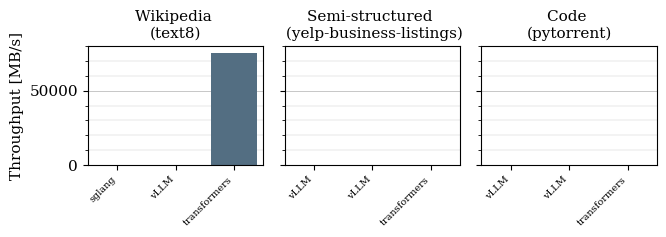

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'medium',
    'text.usetex': False,
})

# Which engines to include in the plot from the CSV file. Also rename them for better readability - transformers, vLLM, sglang, Llama.cpp, Tensor RT, Onnx)

engine_includelist = {
    'transformers': 'transformers',
    'vLLM': 'vLLM',
    'sglang': 'sglang',
    'Llama.cpp': 'Llama.cpp',
    'Tensor RT': 'Tensor RT',
    'Onnx': 'Onnx',
}

df = pd.read_csv('ADMS_engines.csv')

df = df[df['Engine'].isin(engine_includelist.keys())]
df['Engine'] = df['Engine'].map(engine_includelist)
df['Compression Factor'] = df['Dataset Size'] / df['Compressed Size']
df['Throughput [MB/s]'] = df['Dataset Size'] / df['Compression Duration'] / (1024 * 1024)

df = df.sort_values(by='Throughput [MB/s]', ascending=True)
text8_df = df[df['Dataset'] == 'data/text8.txt']
pytorrent_df = df[df['Dataset'] == 'data/pytorrent.jsonl']
yelp_df = df[df['Dataset'] == 'data/yelp_business.jsonl']

matplotlib.rcParams.update({'font.size': 11, 
                            'font.family': 'serif', 
                            'axes.titlesize': 'medium', 
                            'figure.titlesize': 'medium', 
                            'text.usetex': False, # True 
                            'text.latex.preamble': '\\usepackage{amsmath}\\usepackage{amssymb}\\usepackage{siunitx}[=v2]', 
                            'pgf.rcfonts': False, 
                            'pgf.texsystem': 'pdflatex'})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.5), sharey=True)

def get_bar_colors(techniques):
    return ["#253745" if str(t).startswith('LLM') else '#4B6F8A' for t in techniques]

# Throughput for text8
text8_colors = get_bar_colors(text8_df['Engine'])
#sns.barplot(x='Engine', y='Throughput (MB/s)', data=text8_df, ax=axes[0], palette=text8_colors)

sns.barplot(
    x='Engine',
    y='Throughput [MB/s]',
    hue='Engine',
    data=text8_df,
    ax=axes[0],
    palette=text8_colors,
    legend=False
)

axes[0].set_title('Wikipedia \n(text8)')
axes[0].set_xticklabels(text8_df['Engine'], rotation=45, ha='right', fontsize=7)
axes[0].grid(zorder=0)
axes[0].set_axisbelow(True)
axes[0].set_xlabel('')

# Throughput for yelp-business-listings
yelp_colors = get_bar_colors(yelp_df['Engine'])
#sns.barplot(x='Engine', y='Throughput (MB/s)', data=pytorrent_df, ax=axes[1], palette=pytorrent_colors)
sns.barplot(
    x='Engine',
    y='Throughput [MB/s]',
    hue='Engine',
    data=pytorrent_df,
    ax=axes[1],
    palette=yelp_colors,
    legend=False
)

axes[1].set_title('Semi-structured \n (yelp-business-listings)')
axes[1].set_xticklabels(pytorrent_df['Engine'], rotation=45, ha='right', fontsize=7)
axes[1].grid(zorder=0)
axes[1].set_axisbelow(True)
axes[1].set_xlabel('')


# Throughput for pytorrent
pytorrent_colors = get_bar_colors(pytorrent_df['Engine'])
#sns.barplot(x='Engine', y='Throughput (MB/s)', data=pytorrent_df, ax=axes[1], palette=pytorrent_colors)
sns.barplot(
    x='Engine',
    y='Throughput [MB/s]',
    hue='Engine',
    data=pytorrent_df,
    ax=axes[2],
    palette=pytorrent_colors,
    legend=False
)

axes[2].set_title('Code \n(pytorrent)')
axes[2].set_xticklabels(pytorrent_df['Engine'], rotation=45, ha='right', fontsize=7)
axes[2].grid(zorder=0)
axes[2].set_axisbelow(True)
axes[2].set_xlabel('')


# Add more horizontal lines on the y-axis for both subplots
for ax in axes:
    # Make sure the y-axis ends with a major tick
    y_max = ax.get_ylim()[1]
    major_locator = ax.yaxis.get_major_locator()
    major_ticks = major_locator()
    next_major = major_ticks[major_ticks > y_max][0] if any(major_ticks > y_max) else y_max
    ax.set_ylim(ax.get_ylim()[0], next_major)

    # Show grid lines
    ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
    ax.yaxis.grid(True, which='minor', linestyle='-', linewidth=0.2, zorder=0)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.xaxis.grid(False)

plt.tight_layout()
plt.savefig("output_ADMS/throughput_engines_ADMS.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

#### Throughput Plots - per hardware

/tmp/ipykernel_1775797/4126701462.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(text8_df['Hardware'], rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_1775797/4126701462.py:74: UserWarning: 
The palette list has fewer values (0) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/tmp/ipykernel_1775797/4126701462.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(pytorrent_df['Hardware'], rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_1775797/4126701462.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(pytorrent_df['Hardware'], rotation=45, ha='right', fontsize=7)


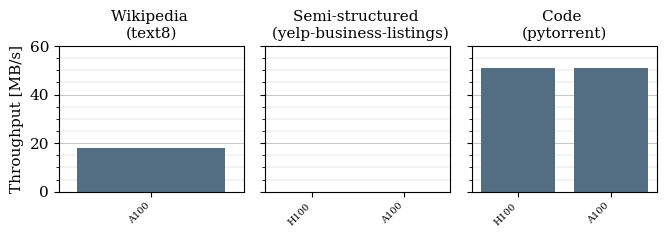

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'medium',
    'text.usetex': False,
})

# Which engines to include in the plot from the CSV file. Also rename them for better readability - transformers, vLLM, sglang, Llama.cpp, Tensor RT, Onnx)

hardware_includelist = {
    'A100': 'A100',
    'H100': 'H100',
    'H200': 'H200',
}

df = pd.read_csv('ADMS_engines.csv')

df = df[df['Hardware'].isin(hardware_includelist.keys())]
df['Hardware'] = df['Hardware'].map(hardware_includelist)
df['Compression Factor'] = df['Dataset Size'] / df['Compressed Size']
df['Throughput [MB/s]'] = df['Dataset Size'] / df['Compression Duration'] / (1024 * 1024)

# This time, filter for engine, e.g. vLLM
df = df[df['Engine'] == 'vLLM']

df = df.sort_values(by='Throughput [MB/s]', ascending=True)
text8_df = df[df['Dataset'] == 'data/text8.txt']
pytorrent_df = df[df['Dataset'] == 'data/pytorrent.jsonl']
yelp_df = df[df['Dataset'] == 'data/yelp_business.jsonl']

matplotlib.rcParams.update({'font.size': 11, 
                            'font.family': 'serif', 
                            'axes.titlesize': 'medium', 
                            'figure.titlesize': 'medium', 
                            'text.usetex': False, # True 
                            'text.latex.preamble': '\\usepackage{amsmath}\\usepackage{amssymb}\\usepackage{siunitx}[=v2]', 
                            'pgf.rcfonts': False, 
                            'pgf.texsystem': 'pdflatex'})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.5), sharey=True)

def get_bar_colors(techniques):
    return ["#253745" if str(t).startswith('LLM') else '#4B6F8A' for t in techniques]

# Throughput for text8
text8_colors = get_bar_colors(text8_df['Engine'])
#sns.barplot(x='Engine', y='Throughput (MB/s)', data=text8_df, ax=axes[0], palette=text8_colors)

sns.barplot(
    x='Engine',
    y='Throughput [MB/s]',
    hue='Engine',
    data=text8_df,
    ax=axes[0],
    palette=text8_colors,
    legend=False
)

axes[0].set_title('Wikipedia \n(text8)')
axes[0].set_xticklabels(text8_df['Hardware'], rotation=45, ha='right', fontsize=7)
axes[0].grid(zorder=0)
axes[0].set_axisbelow(True)
axes[0].set_xlabel('')

# Throughput for yelp-business-listings
yelp_colors = get_bar_colors(yelp_df['Hardware'])
#sns.barplot(x='Engine', y='Throughput (MB/s)', data=pytorrent_df, ax=axes[1], palette=pytorrent_colors)
sns.barplot(
    x='Hardware',
    y='Throughput [MB/s]',
    hue='Hardware',
    data=pytorrent_df,
    ax=axes[1],
    palette=yelp_colors,
    legend=False
)

axes[1].set_title('Semi-structured \n (yelp-business-listings)')
axes[1].set_xticklabels(pytorrent_df['Hardware'], rotation=45, ha='right', fontsize=7)
axes[1].grid(zorder=0)
axes[1].set_axisbelow(True)
axes[1].set_xlabel('')


# Throughput for pytorrent
pytorrent_colors = get_bar_colors(pytorrent_df['Hardware'])
#sns.barplot(x='Engine', y='Throughput (MB/s)', data=pytorrent_df, ax=axes[1], palette=pytorrent_colors)
sns.barplot(
    x='Hardware',
    y='Throughput [MB/s]',
    hue='Hardware',
    data=pytorrent_df,
    ax=axes[2],
    palette=pytorrent_colors,
    legend=False
)

axes[2].set_title('Code \n(pytorrent)')
axes[2].set_xticklabels(pytorrent_df['Hardware'], rotation=45, ha='right', fontsize=7)
axes[2].grid(zorder=0)
axes[2].set_axisbelow(True)
axes[2].set_xlabel('')


# Add more horizontal lines on the y-axis for both subplots
for ax in axes:
    # Make sure the y-axis ends with a major tick
    y_max = ax.get_ylim()[1]
    major_locator = ax.yaxis.get_major_locator()
    major_ticks = major_locator()
    next_major = major_ticks[major_ticks > y_max][0] if any(major_ticks > y_max) else y_max
    ax.set_ylim(ax.get_ylim()[0], next_major)

    # Show grid lines
    ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
    ax.yaxis.grid(True, which='minor', linestyle='-', linewidth=0.2, zorder=0)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.xaxis.grid(False)

plt.tight_layout()
plt.savefig("output_ADMS/throughput_hardware_ADMS.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [79]:
matplotlib.rcParams.update({'font.size': 11, 'font.family': 'serif', 'axes.titlesize': 'medium', 'figure.titlesize': 'medium', 'text.usetex': True, 'text.latex.preamble': '\\usepackage{amsmath}\\usepackage{amssymb}\\usepackage{siunitx}[=v2]', 'pgf.rcfonts': False, 'pgf.texsystem': 'pdflatex'})

# Read an prepare data
df_text8_cpu = pd.read_csv('../text8_c8g.medium_0.019USD.csv')
df_text8_cpu['cost'] = 0.019 / 60 / 60 * df_text8_cpu['time']
df_text8_cpu['orig size'] = 100000000
df_text8_cpu['dataset'] = 'text8'
df_text8_llm = pd.read_csv('../text8_g6e.xlarge_0.804USD.csv')
df_text8_llm['cost'] = 0.804 / 60 / 60 * df_text8_llm['time']
df_text8_llm['orig size'] = 100000000
df_text8_llm['dataset'] = 'text8'
df_pytorrent_cpu = pd.read_csv('../combined_c8g.medium_0.019USD.csv')
df_pytorrent_cpu['cost'] = 0.019 / 60 / 60 * df_pytorrent_cpu['time']
df_pytorrent_cpu['orig size'] = 100000000
df_pytorrent_cpu['dataset'] = 'pytorrent'
df_pytorrent_gpu = pd.read_csv('../combined_g6e.xlarge_0.804USD.csv')
df_pytorrent_gpu['cost'] = 0.804 / 60 / 60 * df_pytorrent_gpu['time']
df_pytorrent_gpu['orig size'] = 100000000
df_pytorrent_gpu['dataset'] = 'pytorrent'

df = pd.concat([df_text8_cpu, df_text8_llm, df_pytorrent_cpu, df_pytorrent_gpu])
df['compression factor'] = df['orig size'] / df['size']
df = df[~df['compressor'].isin(['uncompressed'])]
#df = df.sort_values(by='compression factor', ascending=True)

text8_df = df[df['dataset'] == 'text8']
pytorrent_df = df[df['dataset'] == 'pytorrent']

# Create figure
fig, axes = plt.subplots(3, 2, figsize=(4.9, 2.3 * 3), sharey='row')

def get_bar_colors(techniques):
    return ["#253745" if str(t).startswith('qwen') or str(t).startswith('distil') else '#4B6F8A' for t in techniques]

# Compression factor for text8
ax = axes[0][0]
text8_colors = get_bar_colors(text8_df['compressor'])
sns.barplot(x='compressor', y='compression factor', data=text8_df, ax=ax, palette=text8_colors)
ax.set_title('Wikipedia')
ax.set_xticklabels(text8_df['compressor'], rotation=45, ha='right', fontsize=7)
ax.grid(zorder=0)
ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('')
ax.set_ylabel('Compression Factor')

# Compression factor for text8
ax = axes[0][1]
text8_colors = get_bar_colors(pytorrent_df['compressor'])
sns.barplot(x='compressor', y='compression factor', data=pytorrent_df, ax=ax, palette=text8_colors)
ax.set_title('Code')
ax.set_xticklabels(pytorrent_df['compressor'], rotation=45, ha='right', fontsize=7)
ax.grid(zorder=0)
ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('')

# Compression time for text8
ax = axes[1][0]
text8_colors = get_bar_colors(text8_df['compressor'])
sns.barplot(x='compressor', y='time', data=text8_df, ax=ax, palette=text8_colors)
ax.set_title('Wikipedia')
ax.set_xticklabels(text8_df['compressor'], rotation=45, ha='right', fontsize=7)
ax.grid(zorder=0)
ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('')
ax.set_ylabel('Compression Time [s]')
ax.set_yscale('log')

# Compression time for pytorrent
ax = axes[1][1]
text8_colors = get_bar_colors(pytorrent_df['compressor'])
sns.barplot(x='compressor', y='time', data=pytorrent_df, ax=ax, palette=text8_colors)
ax.set_title('Code')
ax.set_xticklabels(pytorrent_df['compressor'], rotation=45, ha='right', fontsize=7)
ax.grid(zorder=0)
ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('')

# Compression cost for text8
ax = axes[2][0]
text8_colors = get_bar_colors(text8_df['compressor'])
sns.barplot(x='compressor', y='cost', data=text8_df, ax=ax, palette=text8_colors)
ax.set_title('Wikipedia')
ax.set_xticklabels(text8_df['compressor'], rotation=45, ha='right', fontsize=7)
ax.grid(zorder=0)
ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('')
ax.set_ylabel('Cost [USD]')
ax.set_yscale('log')

# Compression cost for pytorrent
ax = axes[2][1]
pytorrent_colors = get_bar_colors(pytorrent_df['compressor'])
sns.barplot(x='compressor', y='cost', data=pytorrent_df, ax=ax, palette=pytorrent_colors)
ax.set_title('Code')
ax.set_xticklabels(pytorrent_df['compressor'], rotation=45, ha='right', fontsize=7)
ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('')

for row in axes:
    for ax in row:
        
        ax.xaxis.grid(False)
        # Make sure the y-axis ends with a major tick
        y_max = ax.get_ylim()[1]
        major_locator = ax.yaxis.get_major_locator()
        major_ticks = major_locator()
        next_major = major_ticks[major_ticks >= y_max][0] if any(major_ticks >= y_max) else y_max
        ax.set_ylim(ax.get_ylim()[0], next_major)

    
plt.tight_layout()
plt.savefig("output_ADMS/compression_overview.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../text8_c8g.medium_0.019USD.csv'